# Intro to Neural Networks
This is the notebook whose plots are submitted for 8th laboratory output in App Physics 157. First, we install Torch and install numpy and matplotlib

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


We'll be training on XOR network, in the following cell, we'll show what's the standard result to serve as benchmark on the other models we'll try

In [2]:
class XORNetwork(nn.Module):
    def __init__(self, hidden=2):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

xor_in = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
xor_out = torch.tensor([0, 1, 1, 0], dtype=torch.float32).unsqueeze(1)

model = XORNetwork(hidden=2) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in).detach().T}")
print(f"Bool output --> {model(xor_in).detach().T > 0.5}")

Epoch 0 	 => 0.12559
Epoch 100 	 => 0.00427
Epoch 200 	 => 0.00095
Epoch 300 	 => 0.00048
Epoch 400 	 => 0.00030
Epoch 500 	 => 0.00021
Epoch 600 	 => 0.00016
Epoch 700 	 => 0.00012
Epoch 800 	 => 0.00010
Epoch 900 	 => 0.00008
Final output --> tensor([[0.0124, 0.9896, 0.9897, 0.0130]])
Bool output --> tensor([[False,  True,  True, False]])


input_layer.weight :: tensor([[-7.1867, -7.1758],
        [ 9.1619,  9.0496]])
input_layer.bias :: tensor([10.5704, -4.3108])
hidden_layer.weight :: tensor([[9.4903, 9.4518]])
hidden_layer.bias :: tensor([-13.9944])


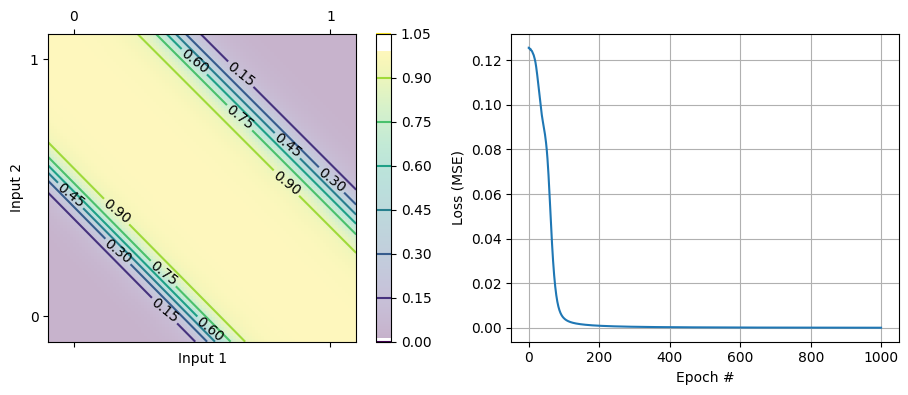

In [3]:
for name, param in model.named_parameters():
    print(f"{name} :: {param.detach()}")


## Feel free to copy the visualization code below, where you
## replace the line `grid_out = model(grid_inputs)` with the
## model you trained.

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")


fig.savefig("raw.pdf")

As we can see, this recovers the standard output, 0 when both of the inputs are the same, and 1 otherwise.
This can be summarized as:
\begin{equation}
A \oplus B = (A + B) \pmod{2}
\end{equation}

This equation shall become especially relevant when dealing with non-binary values for input.

Now, we'll impute the input and output and see if it can still retrieve the function we want

/home/benedict/apphy_gpu/lib/python3.12/site-packages/torch/nn/modules/loss.py:1100: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


Epoch 0 	 => 0.15375
Epoch 100 	 => 0.00003
Epoch 200 	 => 0.00002
Epoch 300 	 => 0.00002
Epoch 400 	 => 0.00001
Epoch 500 	 => 0.00001
Epoch 600 	 => 0.00001
Epoch 700 	 => 0.00001
Epoch 800 	 => 0.00001
Epoch 900 	 => 0.00000
Final output --> tensor([[0.9965, 0.9978]])
Bool output --> tensor([[True, True]])
input_layer.weight :: tensor([[-0.2091,  1.4494],
        [-0.4676,  1.8742]])
input_layer.bias :: tensor([1.8231, 2.0992])
hidden_layer.weight :: tensor([[2.7289, 2.0394]])
hidden_layer.bias :: tensor([1.4865])


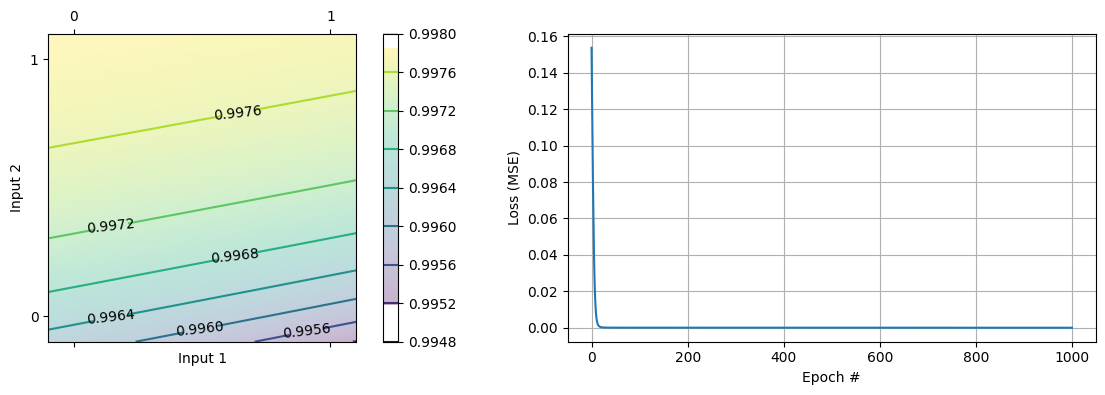

In [4]:
## Variation in Width of the Input and Output
## Varying the width of the hidden layers
class XORNetwork(nn.Module):
    def __init__(self, hidden=2):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

xor_in = torch.tensor([[0,0],[0,1]], dtype=torch.float32)
xor_out = torch.tensor([1], dtype=torch.float32).unsqueeze(1)

model = XORNetwork(hidden=2) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in).detach().T}")
print(f"Bool output --> {model(xor_in).detach().T > 0.5}")

for name, param in model.named_parameters():
    print(f"{name} :: {param.detach()}")


## Feel free to copy the visualization code below, where you
## replace the line `grid_out = model(grid_inputs)` with the
## model you trained.

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")
fig.savefig("double-input-single-output.pdf")


As seen here, the loss is reported to have vanished but did not recover the desired output. It is because we only trained on the data where the output only has 1. So its activation functions lead the machine to think that every input can only have a singular output: 1.

How about if we vary the depth of the hidden layers.

Epoch 0 	 => 0.12539
Epoch 100 	 => 0.00141
Epoch 200 	 => 0.00049
Epoch 300 	 => 0.00027
Epoch 400 	 => 0.00017
Epoch 500 	 => 0.00012
Epoch 600 	 => 0.00009
Epoch 700 	 => 0.00007
Epoch 800 	 => 0.00006
Epoch 900 	 => 0.00005
Final output --> tensor([[0.0087, 0.9897, 0.9922, 0.0084]])
Bool output --> tensor([[False,  True,  True, False]])
input_layer.weight :: tensor([[ 7.9091, -7.9204],
        [ 7.8207, -8.1516]])
input_layer.bias :: tensor([ 4.1174, -4.2660])
hidden_layer.weight :: tensor([[-9.8137, 10.1662]])
hidden_layer.bias :: tensor([4.7806])


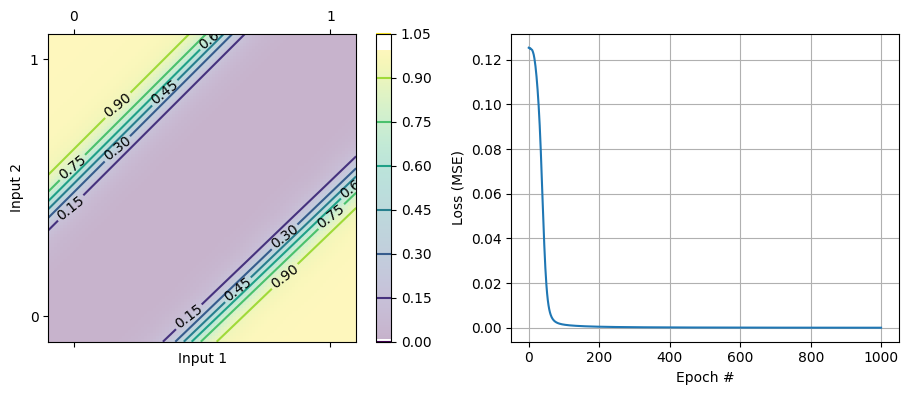

In [5]:
## Varying the depth of the hidden layers
class XORNetwork(nn.Module):
    def __init__(self, hidden=2):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

xor_in = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
xor_out = torch.tensor([0, 1, 1, 0], dtype=torch.float32).unsqueeze(1)

model = XORNetwork(hidden=2) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in).detach().T}")
print(f"Bool output --> {model(xor_in).detach().T > 0.5}")

for name, param in model.named_parameters():
    print(f"{name} :: {param.detach()}")


## Feel free to copy the visualization code below, where you
## replace the line `grid_out = model(grid_inputs)` with the
## model you trained.

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")
fig.savefig("extra-deep-neural networks.pdf")


In the above, we see the desired object and the decline of the loss function is steepoer. This might not be a problem now but for replicating noisier functions than XOR. This could serve as problem, this is what we call **overfitting**.

How about we vary the learning rate towards a smaller rate, would we see a convergence?

Epoch 0 	 => 0.13303
Epoch 100 	 => 0.12821
Epoch 200 	 => 0.12597
Epoch 300 	 => 0.12511
Epoch 400 	 => 0.12484
Epoch 500 	 => 0.12472
Epoch 600 	 => 0.12460
Epoch 700 	 => 0.12443
Epoch 800 	 => 0.12418
Epoch 900 	 => 0.12381
Final output --> tensor([[0.4761, 0.5065, 0.4982, 0.5137]])
Bool output --> tensor([[False,  True, False,  True]])
input_layer.weight :: tensor([[-1.1930, -0.8051],
        [-1.0303,  0.4062]])
input_layer.bias :: tensor([-0.6975, -0.1744])
hidden_layer.weight :: tensor([[-0.6715,  0.2065]])
hidden_layer.bias :: tensor([0.0332])


[Text(0.5, 0, 'Epoch #'), Text(0, 0.5, 'Loss (MSE)')]

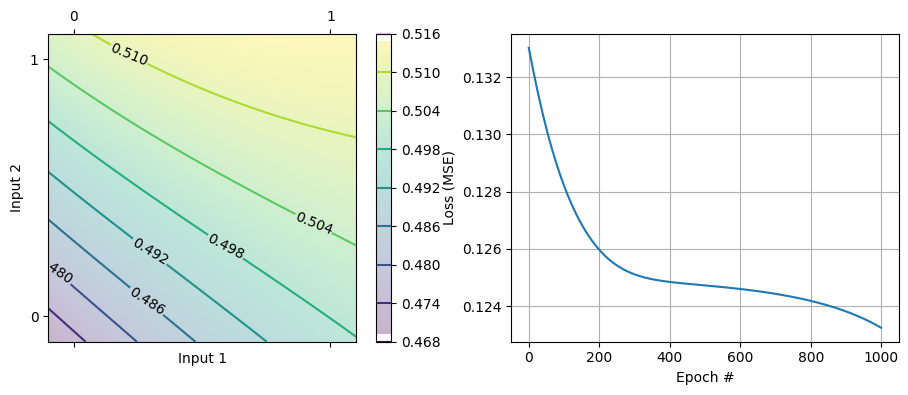

In [6]:
## Varying the width of the hidden layers and learning rate
class XORNetwork(nn.Module):
    def __init__(self, hidden=2):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

xor_in = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
xor_out = torch.tensor([0, 1, 1, 0], dtype=torch.float32).unsqueeze(1)

model = XORNetwork(hidden=2) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in).detach().T}")
print(f"Bool output --> {model(xor_in).detach().T > 0.5}")

for name, param in model.named_parameters():
    print(f"{name} :: {param.detach()}")


## Feel free to copy the visualization code below, where you
## replace the line `grid_out = model(grid_inputs)` with the
## model you trained.

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")


As evidenced by the loss function evolution, the failure to retrieve the output came from small step sizes of the optimizer in finding the extremum. 

Now, we vary the width of each hidden layer from two to four.

Epoch 0 	 => 0.14017
Epoch 100 	 => 0.00294
Epoch 200 	 => 0.00064
Epoch 300 	 => 0.00033
Epoch 400 	 => 0.00021
Epoch 500 	 => 0.00014
Epoch 600 	 => 0.00011
Epoch 700 	 => 0.00008
Epoch 800 	 => 0.00007
Epoch 900 	 => 0.00005
Final output --> tensor([[0.0017, 0.9917, 0.9888, 0.0130]])
Bool output --> tensor([[False,  True,  True, False]])
input_layer.weight :: tensor([[-4.7178,  9.0935],
        [-9.6291,  7.0909],
        [-7.5524, -6.9815],
        [ 6.6990,  6.4886]])
input_layer.bias :: tensor([ 0.4715, -2.8341,  1.6104, -0.9844])
hidden_layer.weight :: tensor([[-9.0789,  9.3921, -3.8337,  3.7941]])
hidden_layer.bias :: tensor([0.8386])


[Text(0.5, 0, 'Epoch #'), Text(0, 0.5, 'Loss (MSE)')]

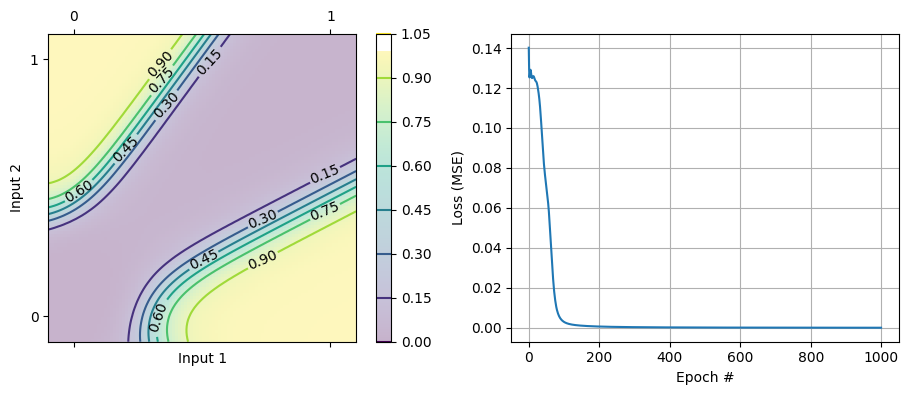

In [7]:
## Varying the width of the hidden layers, and the number of layers
class XORNetwork(nn.Module):
    def __init__(self, hidden=4):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

xor_in = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
xor_out = torch.tensor([0, 1, 1, 0], dtype=torch.float32).unsqueeze(1)

model = XORNetwork(hidden=4) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in).detach().T}")
print(f"Bool output --> {model(xor_in).detach().T > 0.5}")

for name, param in model.named_parameters():
    print(f"{name} :: {param.detach()}")


## Feel free to copy the visualization code below, where you
## replace the line `grid_out = model(grid_inputs)` with the
## model you trained.

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")

Here, overfitting is even more obvious. The output while giving the expected results has replicated even the nonlinearity of the activation functions. This is a waste of computing resources for more expensive functions.

## Changing the Data Type

Epoch 0 	 => 0.11956
Epoch 100 	 => 0.04259
Epoch 200 	 => 0.04201
Epoch 300 	 => 0.04185
Epoch 400 	 => 0.04179
Epoch 500 	 => 0.04175
Epoch 600 	 => 0.04173
Epoch 700 	 => 0.04172
Epoch 800 	 => 0.04171
Epoch 900 	 => 0.04170
Final output --> tensor([[0.0042, 0.3334, 0.3334, 0.0042, 0.9920, 0.0042, 0.3332, 0.9920]])
Bool output --> tensor([[False, False, False, False,  True, False, False,  True]])


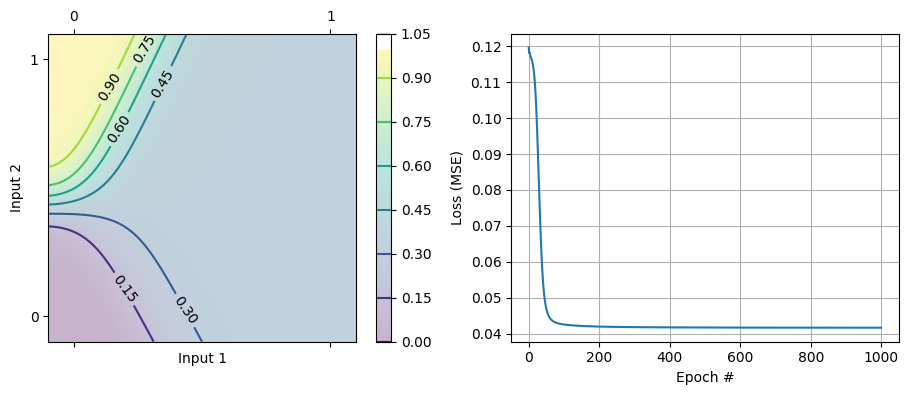

In [12]:
class XORNetwork(nn.Module):
    def __init__(self, hidden=2):
        super(XORNetwork, self).__init__()
        self.input_layer = nn.Linear(in_features=2, out_features=hidden)
        self.hidden_layer = nn.Linear(in_features=hidden, out_features=1)
        self.activ = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activ(self.input_layer(x))
        x = self.activ(self.hidden_layer(x))
        return x

# ---- #

# Number of samples
N = 8  

# Randomized inputs between 0 and 1 using NumPy
xor_in = np.random.rand(N, 2)   # shape (N,2), values in [0,1)

# Binarize inputs via threshold at 0.5
bin_xor_in = (xor_in >= 0.5).astype(np.float32)

# Define XOR output: sum each row and take modulus 2
raw_xor_out = (bin_xor_in.sum(axis=1) % 2).astype(np.float32).reshape(-1,1)

# Convert to torch tensors if needed
xor_in_torch = torch.tensor(bin_xor_in, dtype=torch.float32)
xor_out = torch.tensor(raw_xor_out, dtype=torch.float32)


model = XORNetwork(hidden=2) 
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_list = []

epochs = 1000
for epoch in range(epochs):    
    optimizer.zero_grad()
    pass_output = model(xor_in_torch)
    loss = criterion(pass_output, xor_out)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.detach())
    if epoch % int(epochs/10) ==  0:
        print(f"Epoch {epoch} \t => {loss.detach():.5f}")

print(f"Final output --> {model(xor_in_torch).detach().T}")
print(f"Bool output --> {model(xor_in_torch).detach().T > 0.5}")

ngrid = 100
lat = np.linspace(-0.1, 1.1, ngrid)
X, Y = np.meshgrid(lat, lat)

grid_inputs = torch.as_tensor(np.array([X.ravel(), Y.ravel()]).T, dtype=torch.float32)
grid_out = model(grid_inputs)
grid_out = grid_out.reshape(ngrid, ngrid).detach()

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

ms = axs[0].matshow(grid_out, extent=[np.min(X), np.max(X), np.min(Y), np.max(Y)],
        origin="lower", alpha=0.3)
ct = axs[0].contour(X, Y, grid_out)
cl = axs[0].clabel(ct, inline=True, fontsize=10, colors='black')

axs[0].set(xlabel="Input 1", ylabel="Input 2")
cb = fig.colorbar(ms)
cb2 = fig.colorbar(ct, cax=cb.ax,)

axs[1].plot(loss_list)
axs[1].grid(True)
axs[1].set(xlabel="Epoch #", ylabel="Loss (MSE)")
fig.savefig("random-logic.pdf")

After each iterations, it does not reliably recover the XOR function. It is because your input is completely random and most of the times, it would not span the function. Thus, there are runs when the case 0, 0 leads to 0 and 0,1 leads to 1 are the only cases considered, for example. It might get 1,0, right but not 1,1. Remember Neural Networks learn statistically, not by hard-coding axioms, laws, etc.